# PREDICCIÓN DE LA CALIDAD DEL SUEÑO

El objetivo al que tratamos de llegar se basa en lograr predecir la calidad 
del sueño mediante los datos fisiológicos extraídos de las mediciones con el O2Ring y el test de Pittsburgh  

El problema es de tipo clasificación ya que la variable a predecir es de tipo discreta (calidad del sueño en categorías: "buena", "regular", "mala")

In [98]:
# Importar librerías necesarias
import numpy as np
import time
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as font_manager
import matplotlib.cbook

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.utils import class_weight

from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_curve, auc, confusion_matrix

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

#import utilities
import multiprocessing
#import get_parameters

import pandas as pd
import glob

## 1. CARGAR DATOS

### O2RING

IMPORTAMOS LOS DATOS DEL O2Ring  

Cada paciente está en un csv diferente dentro de la carpeta de O2Ring, por lo que usamos la función glob para encontrar todos los csv (ya que busca archivos que coinciden con un patrón --> /*.csv)

In [99]:
# glob encuentra nombres de archivos que coinciden con un patrón
medic_csv = glob.glob("C:/Users/Marina/OneDrive - Universidad de Burgos/Escritorio/OneDrive - Universidad de Burgos/Escritorio/TFG/O2Ring/*.csv")

In [100]:
# almacenar los datos de cada pacienete
lista_o2ring = []

for archivo in medic_csv:
    pac_data = pd.read_csv(archivo)
    pac_data['Paciente_ID'] = archivo.split('-')[-1].split('.')[0] 
    lista_o2ring.append(pac_data)

# concatenar datos
o2ring = pd.concat(lista_o2ring, ignore_index=True)

#print(data)
o2ring.head()

,Time,SpO2(%),Pulse Rate(bpm),Motion,SpO2 Reminder,PR Reminder,Unnamed: 6,Paciente_ID
0,"12:26:18AM Nov 13, 2024",96,73,0,0,0,NaN,Alvaro
1,"12:26:22AM Nov 13, 2024",96,73,1,0,0,NaN,Alvaro
2,"12:26:26AM Nov 13, 2024",96,74,0,0,0,NaN,Alvaro
3,"12:26:30AM Nov 13, 2024",96,73,1,0,0,NaN,Alvaro
4,"12:26:34AM Nov 13, 2024",96,72,9,0,0,NaN,Alvaro


### TEST DE PITTSBURGH

El test de Pittsburgh ha sido realizado en Google Forms, cada participante lo ha completado de forma individual y con información a cerca de su calidad del sueño durante el último mes


In [101]:
ruta_test = "C:/Users/Marina/OneDrive - Universidad de Burgos/Escritorio/OneDrive - Universidad de Burgos/Escritorio/TFG/TestPittsburgh/Test_Pittsburgh(respuestas)4.csv"
# Leer los datos del Test de Pittsburgh
test_pittsburgh = pd.read_csv(ruta_test)
test_pittsburgh.head(30)

,Marca temporal,Escriba su nombre:,¿Cuál es su edad?,¿Cuánto pesa y cuál es su altura? (kg y cm si es posible),1. ¿Con qué frecuencia ha tenido problemas para quedarse dormido durante el último mes?,2. ¿Con qué frecuencia ha despertado durante la noche y no ha podido volver a dormir?,3. ¿Con qué frecuencia ha tenido dificultad para despertarse por la mañana?,4. ¿Con qué frecuencia se ha sentido cansado o somnoliento durante el día?,5. ¿Con qué frecuencia ha tenido sueños agitados o pesadillas?,6. ¿Con qué frecuencia ha tenido problemas para mantenerse despierto mientras realiza actividades durante el día?,...,"11. ¿Con qué frecuencia ha tenido problemas con el sueño debido a su estado emocional (depresión, estrés, etc.)?",12. ¿Cuánto tiempo tarda habitualmente en quedarse dormido después de acostarse?,13. ¿Cuántas horas de sueño promedio tiene cada noche?,14. ¿Con qué frecuencia ha tenido interrupciones en el sueño debido a ir al baño?,15. ¿Con qué frecuencia ha tenido problemas para dormir debido a preocupaciones o pensamientos?,16. ¿Con qué frecuencia ha tenido dificultades para mantener una rutina regular de sueño (ir a la cama y despertarse a la misma hora cada día)?,17. ¿Con qué frecuencia se siente descansado después de dormir toda la noche?,"18. ¿Con qué frecuencia ha tenido problemas de sueño que han afectado su capacidad para trabajar, estudiar o realizar otras actividades diarias?",19. ¿Con qué frecuencia ha tenido síntomas físicos como dolor o malestar que han afectado a su sueño?,"20. Durante el último mes, ¿cómo valoraría, en conjunto, la calidad de su sueño?"
0,20/11/2024 10:04:39,Marina,22,63 y 170,A veces,Nunca,Nunca,A veces,Nunca,Nunca,...,Nunca,entre 16 y 30 minutos,más de 7 horas,Menos de una vez a la semana,Nunca,A veces,Frecuentemente,Nunca,Nunca,Bastante buena
1,20/11/2024 10:10:59,Paula,21,56 y 174,A veces,Nunca,A veces,Frecuentemente,Frecuentemente,Nunca,...,A veces,entre 16 y 30 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,A veces,A veces,Frecuentemente,Bastante buena
2,20/11/2024 10:14:08,Elena,22,53 y 160,A veces,Nunca,Nunca,Nunca,A veces,A veces,...,A veces,entre 31 minutos y 1 hora,entre 5 -6 horas,Menos de una vez a la semana,A veces,A veces,A veces,Frecuentemente,A veces,Bastante buena
3,20/11/2024 10:17:48,Carmen,21,66 y 163,A veces,Nunca,Siempre,Frecuentemente,A veces,A veces,...,A veces,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,Frecuentemente,A veces,Nunca,Bastante buena
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,Frecuentemente,A veces,Nunca,A veces,A veces,Nunca,...,Frecuentemente,entre 16 y 30 minutos,entre 6 - 7 horas,Menos de una vez a la semana,Frecuentemente,A veces,A veces,A veces,A veces,Bastante buena
5,20/11/2024 11:41:55,Santiago,26,80 y 175,A veces,Nunca,A veces,A veces,Frecuentemente,A veces,...,A veces,entre 16 y 30 minutos,entre 5 -6 horas,Menos de una vez a la semana,A veces,A veces,Frecuentemente,A veces,Nunca,Bastante buena
6,20/11/2024 11:47:42,Alvaro,20,78 y 175,Nunca,Nunca,A veces,A veces,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,Nunca,Frecuentemente,A veces,A veces,A veces,Bastante buena
7,22/11/2024 10:53:51,Jaime,20,115 y 178,Nunca,Nunca,Frecuentemente,Frecuentemente,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,1 o 2 veces a la semana,Nunca,A veces,A veces,A veces,Nunca,Bastante mala
8,24/11/2024 23:22:49,Javier,51,73 kg 174 cm,A veces,Nunca,Nunca,A veces,A veces,A veces,...,A veces,entre 16 y 30 minutos,entre 5 -6 horas,Ninguna vez en el último mes,A veces,A veces,Frecuentemente,A veces,A veces,Bastante buena
9,25/11/2024 8:35:13,Ana,46,57 y 173,Nunca,Nunca,Siempre,A veces,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,Nunca,A veces,A veces,A veces,A veces,Muy buena


### LISTA DE PERSONAS (excel)

In [102]:
# Importar los datos de la lista de personas (excel)
ruta_lista_personas ="C:/Users/Marina/OneDrive - Universidad de Burgos/Escritorio/OneDrive - Universidad de Burgos/Escritorio/TFG/ListaPersonas1.xlsx"


# Leer los datos demográficos de los pacientes
lista_personas = pd.read_excel(ruta_lista_personas)

# Mostrar las primeras filas 
lista_personas.head(25)

,Unnamed: 0,Sujeto,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Qué tal ha dormido,Fecha prueba 2
0,1,Marina,22,63,1.70,21.799308,Femenino,2024-10-24,Mal,NaT
1,2,Alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,Regular,NaT
2,3,PaulaMunoa,20,53,1.63,19.948060,Femenino,2024-11-13,Mal,NaT
3,4,Carmen,21,66,1.63,24.840980,Femenino,2024-11-14,Bien,NaT
4,5,Paula,21,56,1.74,18.496499,Femenino,2024-11-17,Bien pero poco,2024-11-20
5,6,Santiago,26,80,1.75,26.122449,Masculino,2024-11-18,Bien,NaT
6,7,Elena,22,53,1.60,20.703125,Femenino,2024-11-19,Muy bien,NaT
7,8,Jaime,20,115,1.78,36.295922,Masculino,2024-11-21,Bien,NaT
8,9,Javier,51,73,1.74,24.111507,Masculino,2024-12-03,Bien,NaT
9,10,Ana,46,57,1.73,19.045073,Femenino,2024-11-24,Bien,NaT


Comprobamos todos las colecciones cargadas, asi como que podemos visualizarlas antes de continuar con el resto de pasos.

In [103]:
print("Tamaño del dataset O2Ring:", o2ring.shape)
print("Tamaño del test de Pittsburgh:", test_pittsburgh.shape)
print("Tamaño de la lista de personas:", lista_personas.shape)


Tamaño del dataset O2Ring: (160401, 8)
Tamaño del test de Pittsburgh: (25, 24)
Tamaño de la lista de personas: (25, 10)


In [104]:
print("Datos O2Ring: ")
display(o2ring.head())
print("Datos del Test de Pittsburgh: ")
display(test_pittsburgh.head())
print("Datos de la lista de personas: ")
display(lista_personas.head())


Datos O2Ring: 


,Time,SpO2(%),Pulse Rate(bpm),Motion,SpO2 Reminder,PR Reminder,Unnamed: 6,Paciente_ID
0,"12:26:18AM Nov 13, 2024",96,73,0,0,0,NaN,Alvaro
1,"12:26:22AM Nov 13, 2024",96,73,1,0,0,NaN,Alvaro
2,"12:26:26AM Nov 13, 2024",96,74,0,0,0,NaN,Alvaro
3,"12:26:30AM Nov 13, 2024",96,73,1,0,0,NaN,Alvaro
4,"12:26:34AM Nov 13, 2024",96,72,9,0,0,NaN,Alvaro


Datos del Test de Pittsburgh: 


,Marca temporal,Escriba su nombre:,¿Cuál es su edad?,¿Cuánto pesa y cuál es su altura? (kg y cm si es posible),1. ¿Con qué frecuencia ha tenido problemas para quedarse dormido durante el último mes?,2. ¿Con qué frecuencia ha despertado durante la noche y no ha podido volver a dormir?,3. ¿Con qué frecuencia ha tenido dificultad para despertarse por la mañana?,4. ¿Con qué frecuencia se ha sentido cansado o somnoliento durante el día?,5. ¿Con qué frecuencia ha tenido sueños agitados o pesadillas?,6. ¿Con qué frecuencia ha tenido problemas para mantenerse despierto mientras realiza actividades durante el día?,...,"11. ¿Con qué frecuencia ha tenido problemas con el sueño debido a su estado emocional (depresión, estrés, etc.)?",12. ¿Cuánto tiempo tarda habitualmente en quedarse dormido después de acostarse?,13. ¿Cuántas horas de sueño promedio tiene cada noche?,14. ¿Con qué frecuencia ha tenido interrupciones en el sueño debido a ir al baño?,15. ¿Con qué frecuencia ha tenido problemas para dormir debido a preocupaciones o pensamientos?,16. ¿Con qué frecuencia ha tenido dificultades para mantener una rutina regular de sueño (ir a la cama y despertarse a la misma hora cada día)?,17. ¿Con qué frecuencia se siente descansado después de dormir toda la noche?,"18. ¿Con qué frecuencia ha tenido problemas de sueño que han afectado su capacidad para trabajar, estudiar o realizar otras actividades diarias?",19. ¿Con qué frecuencia ha tenido síntomas físicos como dolor o malestar que han afectado a su sueño?,"20. Durante el último mes, ¿cómo valoraría, en conjunto, la calidad de su sueño?"
0,20/11/2024 10:04:39,Marina,22,63 y 170,A veces,Nunca,Nunca,A veces,Nunca,Nunca,...,Nunca,entre 16 y 30 minutos,más de 7 horas,Menos de una vez a la semana,Nunca,A veces,Frecuentemente,Nunca,Nunca,Bastante buena
1,20/11/2024 10:10:59,Paula,21,56 y 174,A veces,Nunca,A veces,Frecuentemente,Frecuentemente,Nunca,...,A veces,entre 16 y 30 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,A veces,A veces,Frecuentemente,Bastante buena
2,20/11/2024 10:14:08,Elena,22,53 y 160,A veces,Nunca,Nunca,Nunca,A veces,A veces,...,A veces,entre 31 minutos y 1 hora,entre 5 -6 horas,Menos de una vez a la semana,A veces,A veces,A veces,Frecuentemente,A veces,Bastante buena
3,20/11/2024 10:17:48,Carmen,21,66 y 163,A veces,Nunca,Siempre,Frecuentemente,A veces,A veces,...,A veces,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,Frecuentemente,A veces,Nunca,Bastante buena
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,Frecuentemente,A veces,Nunca,A veces,A veces,Nunca,...,Frecuentemente,entre 16 y 30 minutos,entre 6 - 7 horas,Menos de una vez a la semana,Frecuentemente,A veces,A veces,A veces,A veces,Bastante buena


Datos de la lista de personas: 


,Unnamed: 0,Sujeto,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Qué tal ha dormido,Fecha prueba 2
0,1,Marina,22,63,1.70,21.799308,Femenino,2024-10-24,Mal,NaT
1,2,Alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,Regular,NaT
2,3,PaulaMunoa,20,53,1.63,19.948060,Femenino,2024-11-13,Mal,NaT
3,4,Carmen,21,66,1.63,24.840980,Femenino,2024-11-14,Bien,NaT
4,5,Paula,21,56,1.74,18.496499,Femenino,2024-11-17,Bien pero poco,2024-11-20


## 2. PREPROCESAMIENTO Y LIMPIEZA DE DATOS

### O2Ring

Se eliminaron las columnas:
- Unnamed: 6, como su nombre indica no tiene ningun tipo de sentido en los distintos csv
- SpO2 Reminder y PR Reminder, yaque  hacen referencia a las alarmas vibratorias del dispositivo  para avisar a los pacientes que están por debajo o encima de algún límite que se ha determinado. En nuestro caso, fueron desactivadas, por lo que no cobran relevancia

In [105]:
# Renombrar columnas
df_o2ring = o2ring.rename(columns={
    "SpO2(%)": "SpO2",
    "Pulse Rate(bpm)": "Frec_Cardiaca",
    "Motion": "Movimiento"
})

# Convertir la columna de tiempo al tipo datetime
df_o2ring["Time"] = pd.to_datetime(df_o2ring["Time"])


# Eliminar columnas innecesarias y valores inválidos
df_o2ring = df_o2ring.drop(columns=["Unnamed: 6","SpO2 Reminder","PR Reminder"])

# La saturación nunca puede estar por encima de 100
df_o2ring = df_o2ring[df_o2ring["SpO2"] <= 100].dropna()


df_o2ring.head()


,Time,SpO2,Frec_Cardiaca,Movimiento,Paciente_ID
0,2024-11-13 00:26:18,96,73,0,Alvaro
1,2024-11-13 00:26:22,96,73,1,Alvaro
2,2024-11-13 00:26:26,96,74,0,Alvaro
3,2024-11-13 00:26:30,96,73,1,Alvaro
4,2024-11-13 00:26:34,96,72,9,Alvaro


### TEST DE PITTSBURGH

In [106]:
# renombrar las columnas
nombres_columnas = {
    "Marca temporal": "Fecha",
    "Escriba su nombre: " : "ID_Paciente",
    "¿Cuál es su edad?": "Edad",
    "¿Cuánto pesa y cuál es su altura? (kg y cm si es posible)": "Peso_Altura",
    "1. ¿Con qué frecuencia ha tenido problemas para quedarse dormido durante el último mes?": "Dormir_Problema",
    "2. ¿Con qué frecuencia ha despertado durante la noche y no ha podido volver a dormir?": "Despertar_Noche",
    "3. ¿Con qué frecuencia ha tenido dificultad para despertarse por la mañana?": "Despertar_Problema",
    "4. ¿Con qué frecuencia se ha sentido cansado o somnoliento durante el día?": "Somnolencia_Dia",
    "5. ¿Con qué frecuencia ha tenido sueños agitados o pesadillas?": "Pesadillas",
    "6. ¿Con qué frecuencia ha tenido problemas para mantenerse despierto mientras realiza actividades durante el día?": "Sueño_Tareas",
    "7. ¿Con qué frecuencia se ha despertado debido a problemas respiratorios (ronquidos, falta de aire, etc.)?": "Despertar_ProblemaRespirat",
    "8. ¿Con qué frecuencia se ha sentido nervioso o ansioso debido a sus problemas de sueño?": "Ansia_ProblSueño",
    "9. ¿Con qué frecuencia ha tenido dificultades para concentrarse durante el día debido a su falta de sueño?": "Concentr_Sueño",
    "10. ¿Con qué frecuencia ha tenido dolor de cabeza por la mañana?": "DolorCabeza_Mañana",
    "11. ¿Con qué frecuencia ha tenido problemas con el sueño debido a su estado emocional (depresión, estrés, etc.)?  ": "ProbSueño_EstadoEmoc",
    "12. ¿Cuánto tiempo tarda habitualmente en quedarse dormido después de acostarse?    ": "Tiempo_Dormir",
    "13. ¿Cuántas horas de sueño promedio tiene cada noche?": "Horas_Sueño",
    "14. ¿Con qué frecuencia ha tenido interrupciones en el sueño debido a ir al baño?": "InterrupSueño_Baño",
    "15. ¿Con qué frecuencia ha tenido problemas para dormir debido a preocupaciones o pensamientos?": "ProblDormir_Preocupac",
    "16. ¿Con qué frecuencia ha tenido dificultades para mantener una rutina regular de sueño (ir a la cama y despertarse a la misma hora cada día)?  ": "Dificultades_RutinaSueño",
    "17. ¿Con qué frecuencia se siente descansado después de dormir toda la noche?  ": "Descansado_Frecuencia",
    "18. ¿Con qué frecuencia  ha tenido problemas de sueño que han afectado su capacidad para trabajar, estudiar o realizar otras actividades diarias?  ": "ProblemasSueño_Trabajar",
    "19. ¿Con qué frecuencia ha tenido síntomas físicos como dolor o malestar que han afectado a su sueño?": "Dolor_AfectaSueño",
    "20. Durante el último mes, ¿cómo valoraría, en conjunto, la calidad de su sueño?": "Calidad_Sueño"
    
}

test_pittsburgh.rename(columns=nombres_columnas, inplace=True)

test_pittsburgh.head(26)


,Fecha,ID_Paciente,Edad,Peso_Altura,Dormir_Problema,Despertar_Noche,Despertar_Problema,Somnolencia_Dia,Pesadillas,Sueño_Tareas,...,ProbSueño_EstadoEmoc,Tiempo_Dormir,Horas_Sueño,InterrupSueño_Baño,ProblDormir_Preocupac,Dificultades_RutinaSueño,Descansado_Frecuencia,ProblemasSueño_Trabajar,Dolor_AfectaSueño,Calidad_Sueño
0,20/11/2024 10:04:39,Marina,22,63 y 170,A veces,Nunca,Nunca,A veces,Nunca,Nunca,...,Nunca,entre 16 y 30 minutos,más de 7 horas,Menos de una vez a la semana,Nunca,A veces,Frecuentemente,Nunca,Nunca,Bastante buena
1,20/11/2024 10:10:59,Paula,21,56 y 174,A veces,Nunca,A veces,Frecuentemente,Frecuentemente,Nunca,...,A veces,entre 16 y 30 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,A veces,A veces,Frecuentemente,Bastante buena
2,20/11/2024 10:14:08,Elena,22,53 y 160,A veces,Nunca,Nunca,Nunca,A veces,A veces,...,A veces,entre 31 minutos y 1 hora,entre 5 -6 horas,Menos de una vez a la semana,A veces,A veces,A veces,Frecuentemente,A veces,Bastante buena
3,20/11/2024 10:17:48,Carmen,21,66 y 163,A veces,Nunca,Siempre,Frecuentemente,A veces,A veces,...,A veces,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,A veces,A veces,Frecuentemente,A veces,Nunca,Bastante buena
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,Frecuentemente,A veces,Nunca,A veces,A veces,Nunca,...,Frecuentemente,entre 16 y 30 minutos,entre 6 - 7 horas,Menos de una vez a la semana,Frecuentemente,A veces,A veces,A veces,A veces,Bastante buena
5,20/11/2024 11:41:55,Santiago,26,80 y 175,A veces,Nunca,A veces,A veces,Frecuentemente,A veces,...,A veces,entre 16 y 30 minutos,entre 5 -6 horas,Menos de una vez a la semana,A veces,A veces,Frecuentemente,A veces,Nunca,Bastante buena
6,20/11/2024 11:47:42,Alvaro,20,78 y 175,Nunca,Nunca,A veces,A veces,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,Nunca,Frecuentemente,A veces,A veces,A veces,Bastante buena
7,22/11/2024 10:53:51,Jaime,20,115 y 178,Nunca,Nunca,Frecuentemente,Frecuentemente,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,1 o 2 veces a la semana,Nunca,A veces,A veces,A veces,Nunca,Bastante mala
8,24/11/2024 23:22:49,Javier,51,73 kg 174 cm,A veces,Nunca,Nunca,A veces,A veces,A veces,...,A veces,entre 16 y 30 minutos,entre 5 -6 horas,Ninguna vez en el último mes,A veces,A veces,Frecuentemente,A veces,A veces,Bastante buena
9,25/11/2024 8:35:13,Ana,46,57 y 173,Nunca,Nunca,Siempre,A veces,A veces,A veces,...,Nunca,menos de 15 minutos,entre 6 - 7 horas,Ninguna vez en el último mes,Nunca,A veces,A veces,A veces,A veces,Muy buena


In [107]:
# MAPEO DE RESPUESTAS DEL TEST DE PITTSBURGH

mapeo_frecuencia = {
    "Nunca": 0, 
    "A veces": 1, 
    "Frecuentemente": 2, 
    "Siempre": 3
}

mapeo_calidad_sueño = {
    "Muy buena": 0,
    "Bastante buena": 1,
    "Bastante mala": 2,
    "Muy mala": 3
}

mapeo_tiempo_dormir = {
    "menos de 15 minutos": 0,
    "entre 16 y 30 minutos": 1,
    "entre 31 minutos y 1 hora": 2,
    "más de 1 hora": 3
}

mapeo_horas_sueño = {
    "más de 7 horas": 0,
    "entre 6 - 7 horas": 1,
    "entre 5 -6 horas": 2,
    "menos de 5 horas": 3
}

mapeo_interrupcion_sueño = {
    "Ninguna vez en el último mes": 0,
    "Menos de una vez a la semana": 1,
    "1 o 2 veces a la semana": 2,
    "3 o más veces a la semana": 3
}

# APLICAR MAPEO A LAS COLUMNAS CORRESPONDIENTES
columnas_frecuencia = [
    "Dormir_Problema", "Despertar_Noche", "Despertar_Problema", "Somnolencia_Dia",
    "Pesadillas", "Sueño_Tareas", "Despertar_ProblemaRespirat", "Ansia_ProblSueño",
    "Concentr_Sueño", "DolorCabeza_Mañana", "ProbSueño_EstadoEmoc",
    "ProblDormir_Preocupac", "Dificultades_RutinaSueño", "Descansado_Frecuencia",
    "ProblemasSueño_Trabajar", "Dolor_AfectaSueño"
]

for col in columnas_frecuencia:
    test_pittsburgh[col] = test_pittsburgh[col].map(mapeo_frecuencia)

test_pittsburgh["Tiempo_Dormir"] = test_pittsburgh["Tiempo_Dormir"].map(mapeo_tiempo_dormir)
test_pittsburgh["Horas_Sueño"] = test_pittsburgh["Horas_Sueño"].map(mapeo_horas_sueño)
test_pittsburgh["InterrupSueño_Baño"] = test_pittsburgh["InterrupSueño_Baño"].map(mapeo_interrupcion_sueño)
test_pittsburgh["Calidad_Sueño"] = test_pittsburgh["Calidad_Sueño"].map(mapeo_calidad_sueño)

# IMPRIMIR RESULTADOS PARA VERIFICAR LIMPIEZA
test_pittsburgh.head()


,Fecha,ID_Paciente,Edad,Peso_Altura,Dormir_Problema,Despertar_Noche,Despertar_Problema,Somnolencia_Dia,Pesadillas,Sueño_Tareas,...,ProbSueño_EstadoEmoc,Tiempo_Dormir,Horas_Sueño,InterrupSueño_Baño,ProblDormir_Preocupac,Dificultades_RutinaSueño,Descansado_Frecuencia,ProblemasSueño_Trabajar,Dolor_AfectaSueño,Calidad_Sueño
0,20/11/2024 10:04:39,Marina,22,63 y 170,1,0,0,1,0,0,...,0,1,0,1,0,1,2,0,0,1.0
1,20/11/2024 10:10:59,Paula,21,56 y 174,1,0,1,2,2,0,...,1,1,1,0,1,1,1,1,2,1.0
2,20/11/2024 10:14:08,Elena,22,53 y 160,1,0,0,0,1,1,...,1,2,2,1,1,1,1,2,1,1.0
3,20/11/2024 10:17:48,Carmen,21,66 y 163,1,0,3,2,1,1,...,1,0,1,0,1,1,2,1,0,1.0
4,20/11/2024 10:21:23,PaulaMunoa,20,52 y 163,2,1,0,1,1,0,...,2,1,1,1,2,1,1,1,1,1.0


### LISTA PERSONAS (excel)

In [108]:
# Renombrar la columna "Sujeto" a "Paciente_ID" en lista_personas
lista_personas.rename(columns={"Sujeto": "Paciente_ID"}, inplace=True)
lista_personas = lista_personas.drop(columns=["Unnamed: 0", "Fecha prueba 2"], errors="ignore")

lista_personas.head(25)

,Paciente_ID,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Qué tal ha dormido
0,Marina,22,63,1.70,21.799308,Femenino,2024-10-24,Mal
1,Alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,Regular
2,PaulaMunoa,20,53,1.63,19.948060,Femenino,2024-11-13,Mal
3,Carmen,21,66,1.63,24.840980,Femenino,2024-11-14,Bien
4,Paula,21,56,1.74,18.496499,Femenino,2024-11-17,Bien pero poco
5,Santiago,26,80,1.75,26.122449,Masculino,2024-11-18,Bien
6,Elena,22,53,1.60,20.703125,Femenino,2024-11-19,Muy bien
7,Jaime,20,115,1.78,36.295922,Masculino,2024-11-21,Bien
8,Javier,51,73,1.74,24.111507,Masculino,2024-12-03,Bien
9,Ana,46,57,1.73,19.045073,Femenino,2024-11-24,Bien


In [109]:
# 1. Convertir 'Sexo' a valores numéricos
mapa_sexo = {"Femenino": 0, "Masculino": 1}
lista_personas["Sexo_Codificado"] = lista_personas["Sexo"].map(mapa_sexo)

# 2. Normalizar 'Qué tal ha dormido'
mapa_sueño = {
    "Muy bien": 5,
    "Bien": 4,
    "Bien pero poco": 3,
    "Regular": 2,
    "Mal": 1
}
lista_personas["Calidad_Sueño_Subjet"] = lista_personas[" Qué tal ha dormido"].map(mapa_sueño)

# 3. Convertir 'Fecha prueba 1' a formato datetime
lista_personas["Fecha prueba 1"] = pd.to_datetime(lista_personas["Fecha prueba 1"], errors="coerce")

# 4. Verificar y manejar valores nulos
print("Valores nulos antes de limpieza:")
print(lista_personas.isnull().sum())

# Si hay valores nulos en 'Calidad_Sueño_Label' o 'Sexo_Codificado', eliminarlos
lista_personas.dropna(subset=["Calidad_Sueño_Subjet", "Sexo_Codificado"], inplace=True)

# 5. Verificar la corrección de IMC
lista_personas["IMC_Calculado"] = lista_personas["Peso (kg)"] / (lista_personas["Altura (m)"] ** 2)
lista_personas["IMC_Diferencia"] = abs(lista_personas["IMC"] - lista_personas["IMC_Calculado"])
print("Diferencias en IMC calculado:")
print(lista_personas[lista_personas["IMC_Diferencia"] > 0.01][["Paciente_ID", "IMC", "IMC_Calculado"]])

# 6. Mostrar los primeros datos después del preprocesamiento
print("Datos después del preprocesamiento:")
lista_personas.head()


Valores nulos antes de limpieza:
Paciente_ID             0
Edad (años)             0
Peso (kg)               0
Altura (m)              0
IMC                     0
Sexo                    0
Fecha prueba 1          0
 Qué tal ha dormido     0
Sexo_Codificado         0
Calidad_Sueño_Subjet    6
dtype: int64
Diferencias en IMC calculado:
Empty DataFrame
Columns: [Paciente_ID, IMC, IMC_Calculado]
Index: []
Datos después del preprocesamiento:


,Paciente_ID,Edad (años),Peso (kg),Altura (m),IMC,Sexo,Fecha prueba 1,Qué tal ha dormido,Sexo_Codificado,Calidad_Sueño_Subjet,IMC_Calculado,IMC_Diferencia
1,Alvaro,20,78,1.75,25.469388,Masculino,2024-11-12,Regular,1,2.0,25.469388,0.0
3,Carmen,21,66,1.63,24.840980,Femenino,2024-11-14,Bien,0,4.0,24.840980,0.0
4,Paula,21,56,1.74,18.496499,Femenino,2024-11-17,Bien pero poco,0,3.0,18.496499,0.0
6,Elena,22,53,1.60,20.703125,Femenino,2024-11-19,Muy bien,0,5.0,20.703125,0.0
7,Jaime,20,115,1.78,36.295922,Masculino,2024-11-21,Bien,1,4.0,36.295922,0.0


En este último dataset, se han realizado las siguientes modificaciones:
- Se ha codificado la variables sexo, convirtiendo a 0 (Femenino) y 1 (Masculino).
- Se ha mapeado "Qué tal ha dormido" para crear la vasriable "Calidad_Sueño_Subjet" con valores del 1 al 5.
- Se ha probado que el IMC calculado era exactamente el IMC por lo que no hay errores.
- "Fecha prueba 1" también ha sido convertido a formato datetime.

In [110]:
# Por último, eliminamos las columnas que no son necesarias tras el preprocesamiento

# Eliminamos Qué tal ha dormido porque Calidad_Sueño_Subjet la reemplaza
lista_personas.drop(columns=[" Qué tal ha dormido"], inplace=True)


In [111]:
# Eliminar IMC_Calculado y IMC_Diferencia ya que hemos hecho la comprobacion y es correcto
lista_personas.drop(columns=["IMC_Calculado", "IMC_Diferencia"], inplace=True)


In [112]:
# Revisamos los valores nulos por último
print(lista_personas.isnull().sum())


Paciente_ID             0
Edad (años)             0
Peso (kg)               0
Altura (m)              0
IMC                     0
Sexo                    0
Fecha prueba 1          0
Sexo_Codificado         0
Calidad_Sueño_Subjet    0
dtype: int64


## 3. EXPLORACIÓN VISUAL Y ANÁLISIS INICIAL

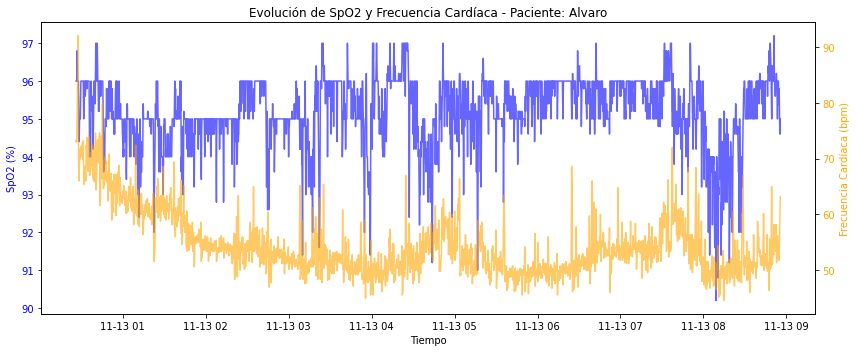

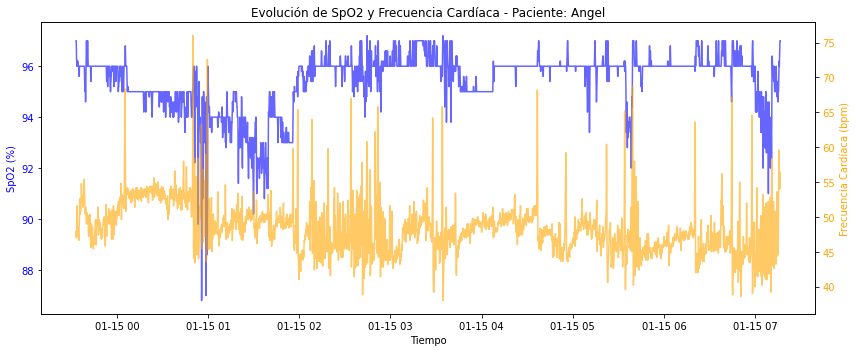

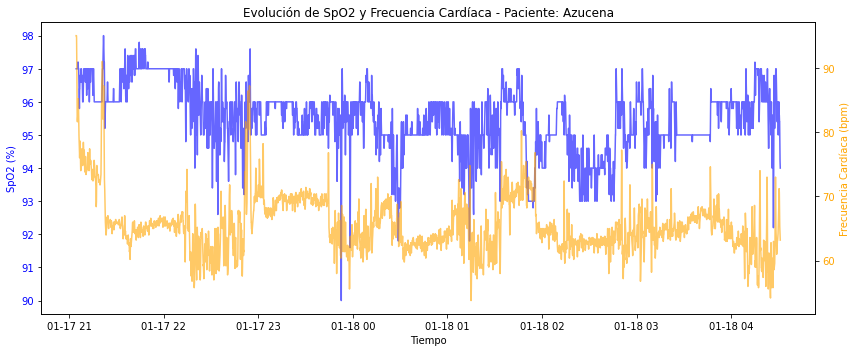

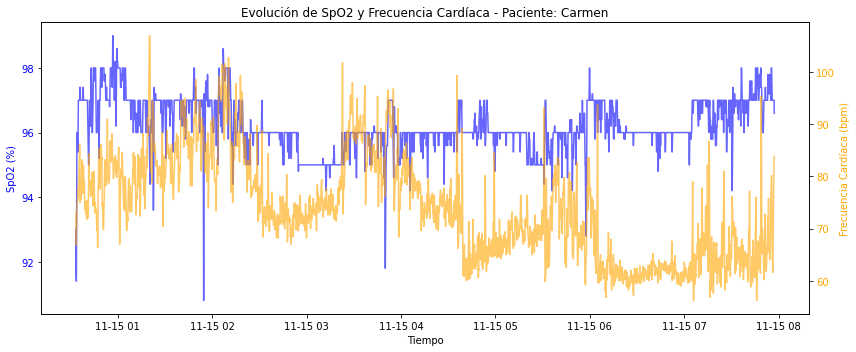

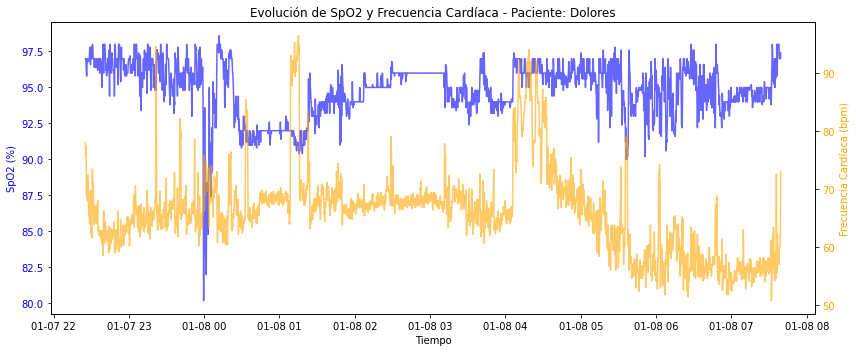

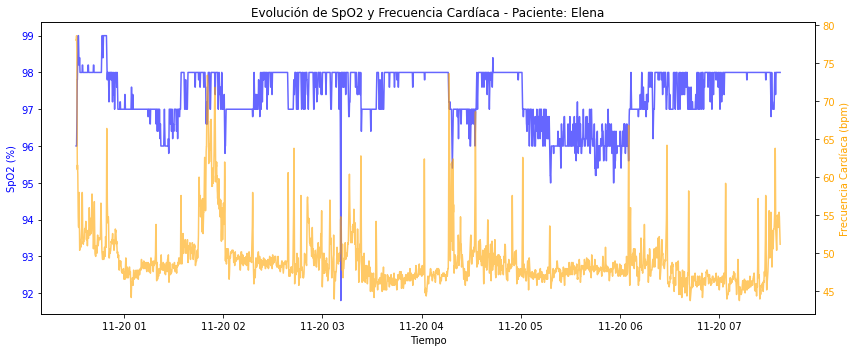

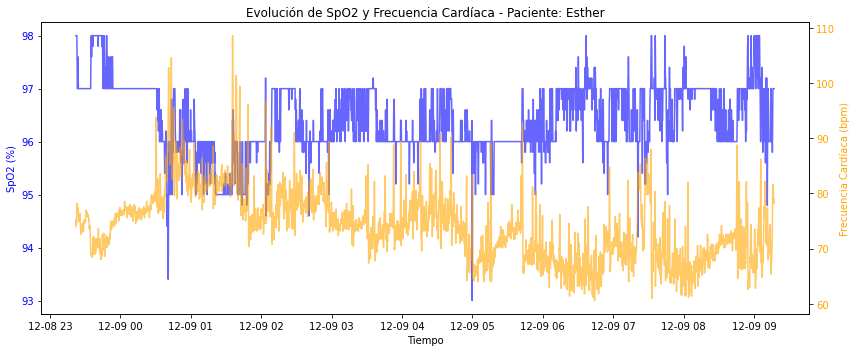

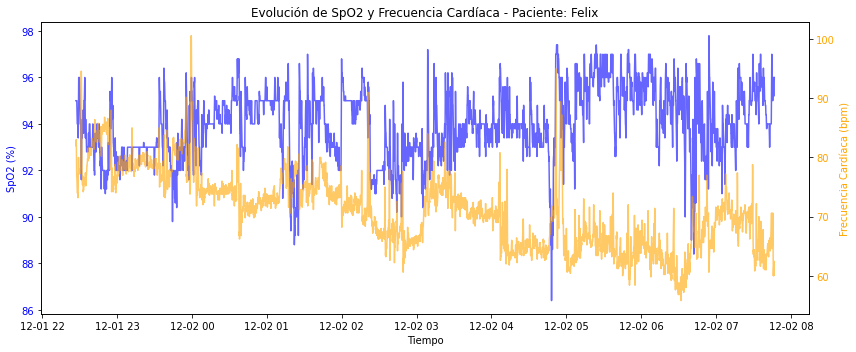

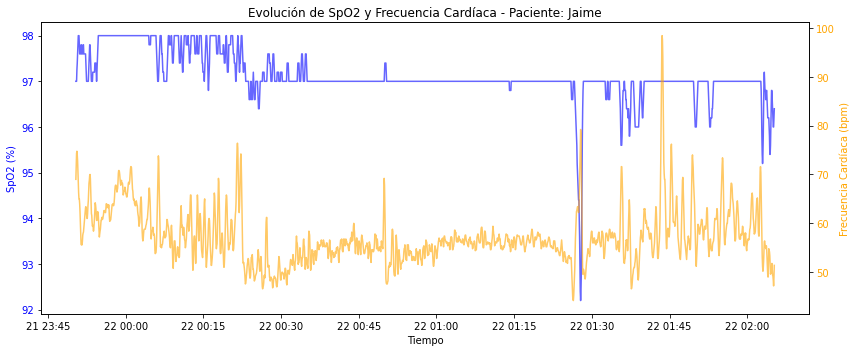

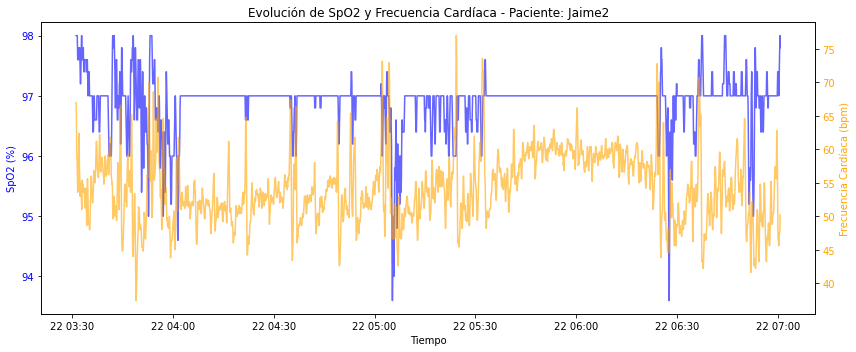

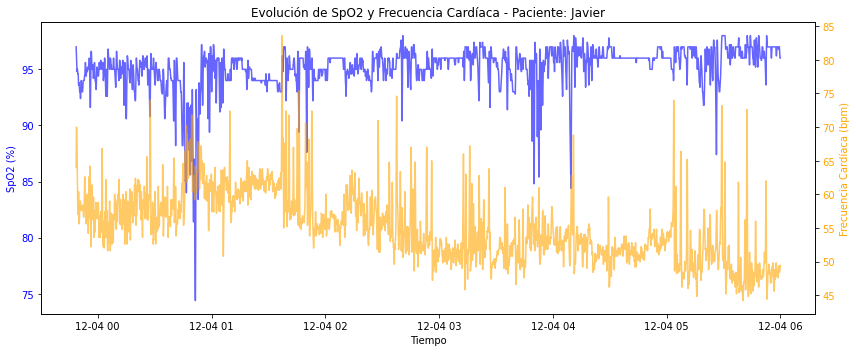

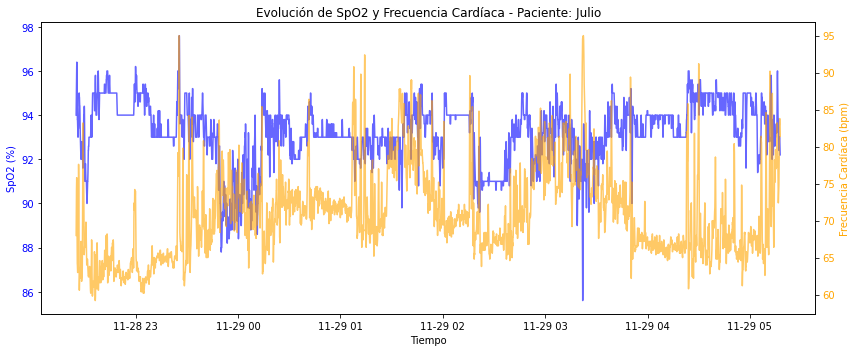

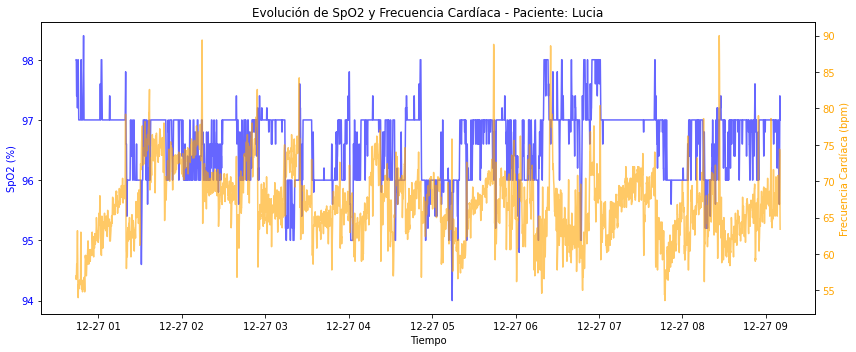

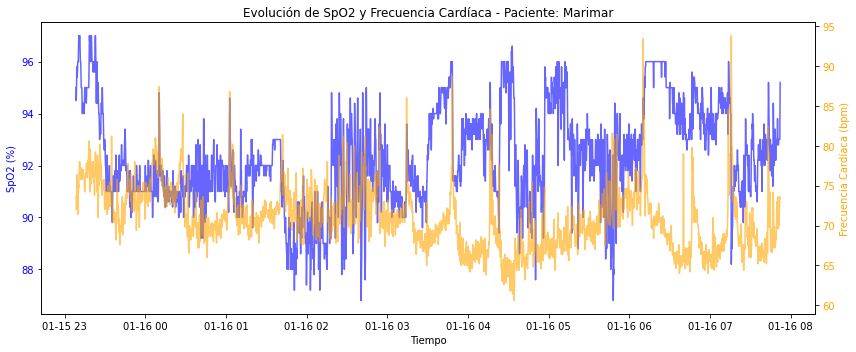

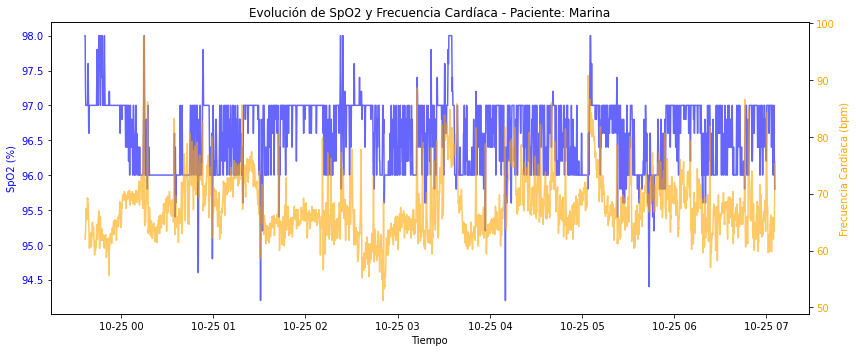

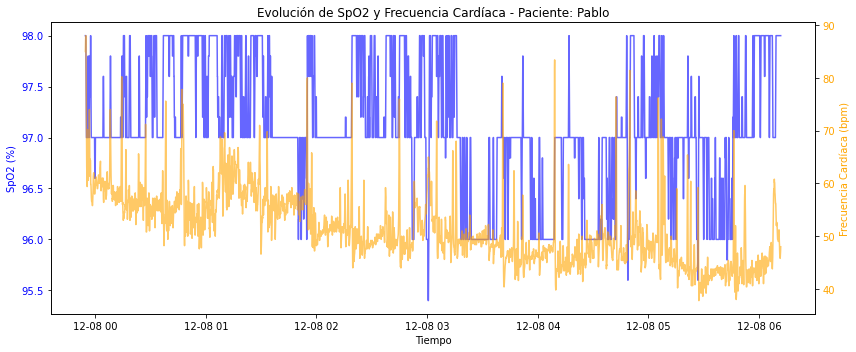

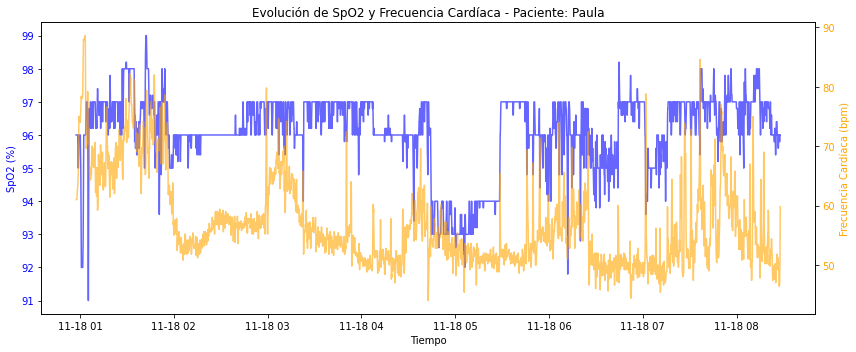

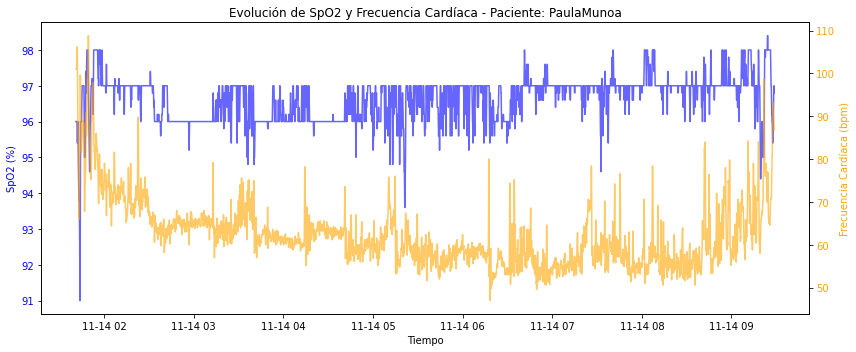

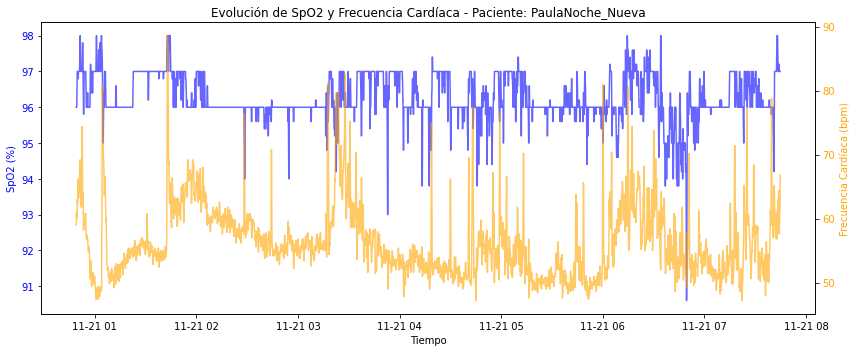

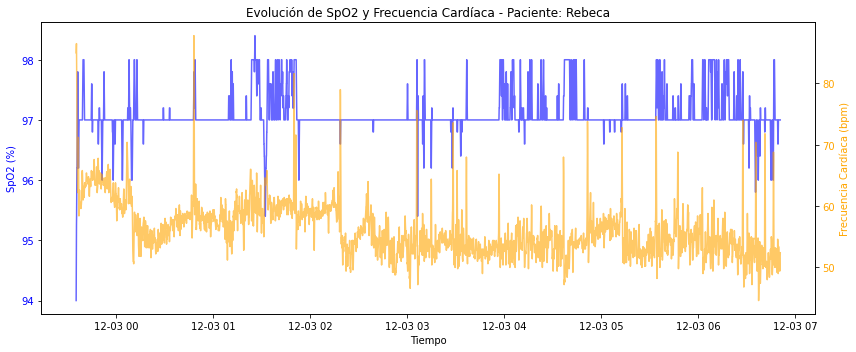

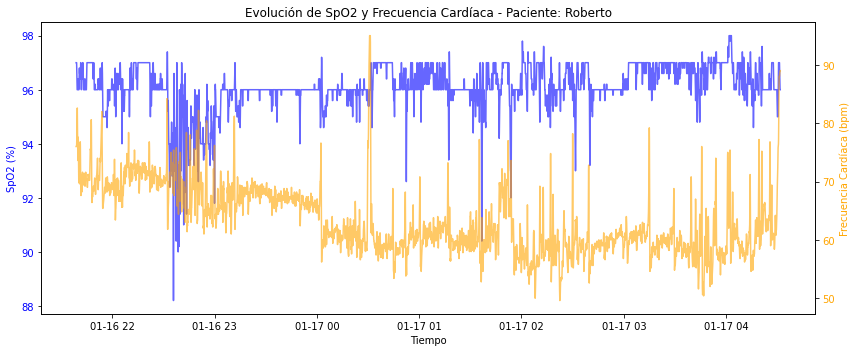

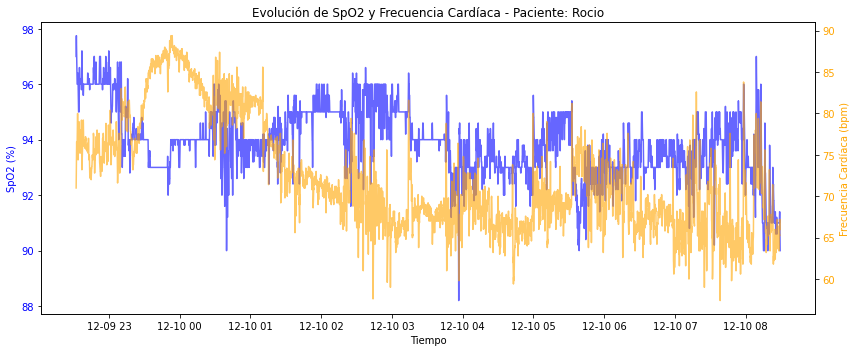

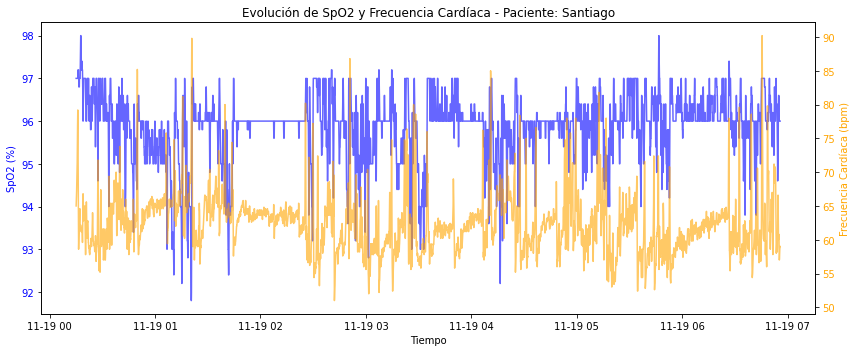

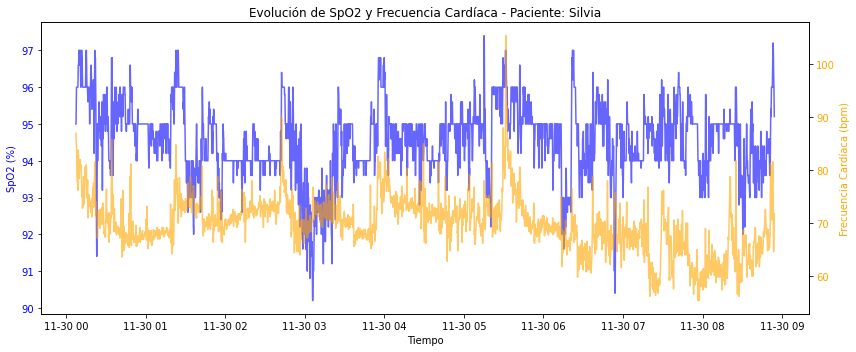

In [113]:
# Asegurar que los datos estén ordenados por paciente y tiempo
df_o2ring = df_o2ring.sort_values(by=["Paciente_ID", "Time"])

# Filtrar valores extremos si los hubiera
df_o2ring = df_o2ring[(df_o2ring['SpO2'] >= 70) & (df_o2ring['Frec_Cardiaca'] <= 200)]

# Crear gráficos por paciente
pacientes = df_o2ring["Paciente_ID"].unique()

for paciente_id in pacientes:
    datos_paciente = df_o2ring[df_o2ring["Paciente_ID"] == paciente_id].copy()
    
    # Suavizar los datos con media móvil
    datos_paciente["SpO2_suavizado"] = datos_paciente["SpO2"].rolling(window=5, min_periods=1).mean()
    datos_paciente["Frec_Cardiaca_suavizado"] = datos_paciente["Frec_Cardiaca"].rolling(window=5, min_periods=1).mean()
    
    # Graficar
    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.set_xlabel("Tiempo")
    ax1.set_ylabel("SpO2 (%)", color="blue")
    ax1.plot(datos_paciente["Time"], datos_paciente["SpO2_suavizado"], label="SpO2", color="blue", alpha=0.6)
    ax1.tick_params(axis="y", labelcolor="blue")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Frecuencia Cardíaca (bpm)", color="orange")
    ax2.plot(datos_paciente["Time"], datos_paciente["Frec_Cardiaca_suavizado"], label="Frecuencia Cardíaca", color="orange", alpha=0.6)
    ax2.tick_params(axis="y", labelcolor="orange")

    plt.title(f"Evolución de SpO2 y Frecuencia Cardíaca - Paciente: {paciente_id}")
    fig.tight_layout()
    plt.show()

#### ANÁLISIS ESTADÍSTICO INICIAL

Estadísticas Descriptivas:
                 SpO2  Frec_Cardiaca
count  160338.000000  160338.000000
mean       95.535120      63.352381
std         1.758959      10.196354
min        73.000000      36.000000
25%        95.000000      55.000000
50%        96.000000      64.000000
75%        97.000000      70.000000
max        99.000000     113.000000


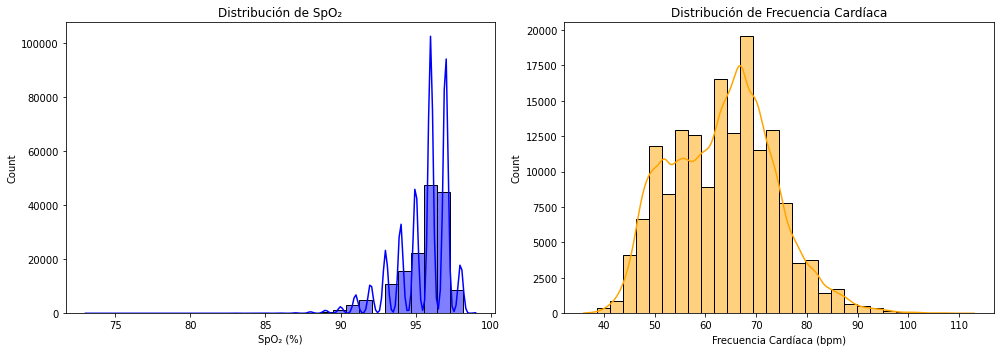

In [114]:
# Calcular estadísticas básicas
estadisticas = df_o2ring[['SpO2', 'Frec_Cardiaca']].describe()
print("Estadísticas Descriptivas:\n", estadisticas)

# Histogramas para visualizar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_o2ring['SpO2'], bins=30, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Distribución de SpO₂")
axes[0].set_xlabel("SpO₂ (%)")

sns.histplot(df_o2ring['Frec_Cardiaca'], bins=30, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribución de Frecuencia Cardíaca")
axes[1].set_xlabel("Frecuencia Cardíaca (bpm)")

plt.tight_layout()
plt.show()

La saturación de oxígeno se encuentra entre el 73 y el 99%, con una media de 95.53. 

La frecuencia cardíaca entre  y 113 pulsaciones por minuto, con una media de  63.35.

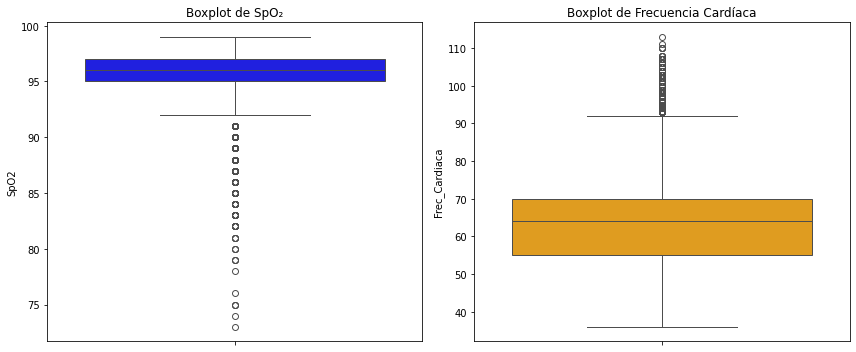

In [115]:
# Boxplots para detectar valores atípicos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_o2ring['SpO2'], ax=axes[0], color="blue")
axes[0].set_title("Boxplot de SpO₂")

sns.boxplot(y=df_o2ring['Frec_Cardiaca'], ax=axes[1], color="orange")
axes[1].set_title("Boxplot de Frecuencia Cardíaca")

plt.tight_layout()
plt.show()

SpO₂: Se observan valores atípicos por debajo de 90%.

Frecuencia Cardíaca: Muchos valores atípicos por encima de 100 bpm y por debajo de 50 bpm.

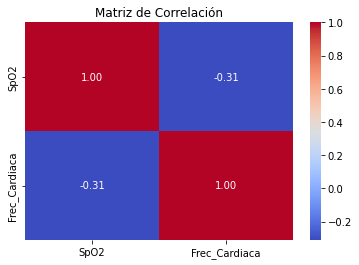

In [116]:
# Matriz de correlación
plt.figure(figsize=(6, 4))
sns.heatmap(df_o2ring[['SpO2', 'Frec_Cardiaca']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

Existe una correlación negativa moderada entre la saturación y la frecuecnia cardíaca, de un -0.31. 

Esto quiere decir que cuando la saturación disminuye, la frecuecnía cardíaca tiende a subir. Esto tiene sentido fisiológico puesto que el corazón puede compensar una menor oxigenación aumentando la frecuencia cardíaca.

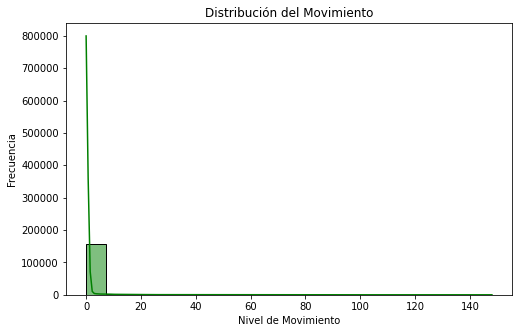

In [117]:
# DISTRIBUCION DEL MOVIMIENTO
plt.figure(figsize=(8, 5))
sns.histplot(df_o2ring["Movimiento"], bins=20, kde=True, color="green")
plt.title("Distribución del Movimiento")
plt.xlabel("Nivel de Movimiento")
plt.ylabel("Frecuencia")
plt.show()


La mayoría de los valores de "Movimiento" están concentrados en valores muy bajos, cercanos a 0.

Existen ciertos valores mucho más altos (hasta 140), pero son muy raros.

<ipython-input-118-84aa74187327>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_o2ring["Movimiento"], y=df_o2ring["SpO2"], palette="Blues")
<ipython-input-118-84aa74187327>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_o2ring["Movimiento"], y=df_o2ring["Frec_Cardiaca"], palette="Oranges")


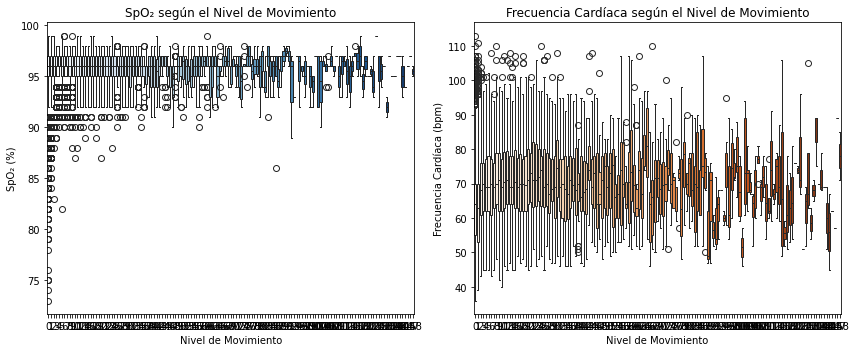

In [118]:
# RELACION ENTRE EL MOVIMIENTO Y OTRAS VARIABLES
plt.figure(figsize=(12, 5))

# Boxplot de SpO₂ por niveles de movimiento
plt.subplot(1, 2, 1)
sns.boxplot(x=df_o2ring["Movimiento"], y=df_o2ring["SpO2"], palette="Blues")
plt.title("SpO₂ según el Nivel de Movimiento")
plt.xlabel("Nivel de Movimiento")
plt.ylabel("SpO₂ (%)")

# Boxplot de Frecuencia Cardíaca por niveles de movimiento
plt.subplot(1, 2, 2)
sns.boxplot(x=df_o2ring["Movimiento"], y=df_o2ring["Frec_Cardiaca"], palette="Oranges")
plt.title("Frecuencia Cardíaca según el Nivel de Movimiento")
plt.xlabel("Nivel de Movimiento")
plt.ylabel("Frecuencia Cardíaca (bpm)")

plt.tight_layout()
plt.show()

SpO2 vs Movimiento (Izquierda): 
- La saturación de oxígeno (SpO2) tiende a mantenerse estable alrededor del 95-100%, sin importar el nivel de movimiento.
- Sin embargo, hay algunos valores más bajos cuando hay movimiento, lo que podría indicar eventos de desaturación relacionados con actividad.


Frecuencia Cardíaca vs Movimiento (Derecha): 
- La frecuencia cardíaca aumenta con el movimiento, lo que es esperable.
- Hay mucha variabilidad en los valores cuando el movimiento es mayor, lo que indica que algunos pacientes pueden tener una respuesta cardíaca más fuerte que otros.


CONCLUSIONES:

- La relación entre movimiento y SpO2 es débil, pero puede haber eventos de desaturación en movimientos altos.
- La frecuencia cardíaca sí está afectada por el movimiento, aumentando conforme el movimiento es mayor.

#### DETECCIÓN DE VALORES ATÍPICOS

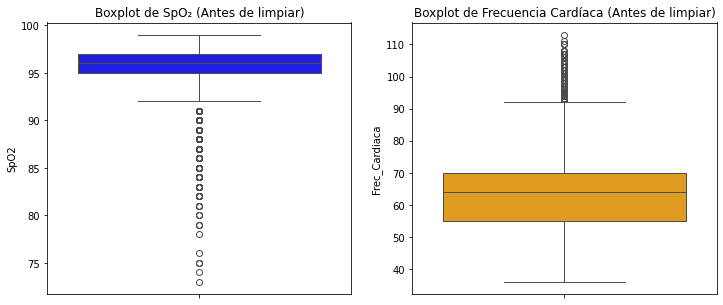

In [119]:
# Comparar los datos originales con los valores atípicos detectados
plt.figure(figsize=(12, 5))

# Boxplot antes de eliminar valores atípicos
plt.subplot(1, 2, 1)
sns.boxplot(y=df_o2ring['SpO2'], color="blue")
plt.title("Boxplot de SpO₂ (Antes de limpiar)")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_o2ring['Frec_Cardiaca'], color="orange")
plt.title("Boxplot de Frecuencia Cardíaca (Antes de limpiar)")

plt.show()


In [120]:
print(df_o2ring.head())  # Ver las primeras filas
print(df_o2ring.columns)  # Ver los nombres de las columnas
print(df_o2ring.info())  # Ver información general del DataFrame


                 Time  SpO2  Frec_Cardiaca  Movimiento Paciente_ID
0 2024-11-13 00:26:18    96             73           0      Alvaro
1 2024-11-13 00:26:22    96             73           1      Alvaro
2 2024-11-13 00:26:26    96             74           0      Alvaro
3 2024-11-13 00:26:30    96             73           1      Alvaro
4 2024-11-13 00:26:34    96             72           9      Alvaro
Index(['Time', 'SpO2', 'Frec_Cardiaca', 'Movimiento', 'Paciente_ID'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
Int64Index: 160338 entries, 0 to 160398
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Time           160338 non-null  datetime64[ns]
 1   SpO2           160338 non-null  int64         
 2   Frec_Cardiaca  160338 non-null  int64         
 3   Movimiento     160338 non-null  int64         
 4   Paciente_ID    160338 non-null  object        
dtypes: datetime64[ns](1), int64(3), o

##### A) MÉTODO DEL RANGO INTERCUARTÍLICO (IQR)

El IQR es una de las maneras más comunes de identificar valores atípicos. La idea es calcular los cuartiles (Q1 y Q3) y luego encontrar cualquier valor que esté fuera del rango intercuartílico definido por:

    Límite Inferior = Q1 - 1.5 x IQR
    Límmite Superior = Q3 + 1.5 x IQR
     
Cualquier valor fuera de estos límites puede condirarse un valor atípico.

In [121]:
# Calcular los cuartiles y el IQR para SpO2 y Frecuencia Cardíaca
Q1_spo2 = df_o2ring['SpO2'].quantile(0.25)
Q3_spo2 = df_o2ring['SpO2'].quantile(0.75)
IQR_spo2 = Q3_spo2 - Q1_spo2

Q1_fc = df_o2ring['Frec_Cardiaca'].quantile(0.25)
Q3_fc = df_o2ring['Frec_Cardiaca'].quantile(0.75)
IQR_fc = Q3_fc - Q1_fc

# Detectar los valores atípicos
limite_inferior_spo2 = Q1_spo2 - 1.5 * IQR_spo2
limite_superior_spo2 = Q3_spo2 + 1.5 * IQR_spo2
valores_atipicos_spo2 = df_o2ring[(df_o2ring['SpO2'] < limite_inferior_spo2) | (df_o2ring['SpO2'] > limite_superior_spo2)]

limite_inferior_fc = Q1_fc - 1.5 * IQR_fc
limite_superior_fc = Q3_fc + 1.5 * IQR_fc
valores_atipicos_fc = df_o2ring[(df_o2ring['Frec_Cardiaca'] < limite_inferior_fc) | (df_o2ring['Frec_Cardiaca'] > limite_superior_fc)]

# Verificar los valores atípicos
print(valores_atipicos_spo2)
print(valores_atipicos_fc)


                      Time  SpO2  Frec_Cardiaca  Movimiento Paciente_ID
680    2024-11-13 01:11:38    91             63           0      Alvaro
681    2024-11-13 01:11:42    91             54           0      Alvaro
697    2024-11-13 01:12:46    91             62           0      Alvaro
840    2024-11-13 01:22:18    91             52           0      Alvaro
841    2024-11-13 01:22:22    91             55           0      Alvaro
...                    ...   ...            ...         ...         ...
158594 2024-11-30 06:53:50    90             74           1      Silvia
158595 2024-11-30 06:53:54    90             73           1      Silvia
158596 2024-11-30 06:53:58    90             76           1      Silvia
158597 2024-11-30 06:54:02    91             77           1      Silvia
158598 2024-11-30 06:54:06    91             75           1      Silvia

[5291 rows x 5 columns]
                      Time  SpO2  Frec_Cardiaca  Movimiento Paciente_ID
17     2024-11-13 00:27:26    96       

##### B) MÉTODO Z-SCORE

In [122]:
from scipy.stats import zscore

# Calcular el Z-Score para SpO2 y Frecuencia Cardíaca
df_o2ring['z_spo2'] = zscore(df_o2ring['SpO2'])
df_o2ring['z_fc'] = zscore(df_o2ring['Frec_Cardiaca'])

# Valores atípicos según Z-Score
valores_atipicos_z_spo2 = df_o2ring[df_o2ring['z_spo2'].abs() > 3]
valores_atipicos_z_fc = df_o2ring[df_o2ring['z_fc'].abs() > 3]

print(valores_atipicos_z_spo2)
print(valores_atipicos_z_fc)


                      Time  SpO2  Frec_Cardiaca  Movimiento Paciente_ID  \
2453   2024-11-13 03:09:50    90             59           0      Alvaro   
2564   2024-11-13 03:17:14    90             55           0      Alvaro   
6938   2024-11-13 08:08:50    90             49           0      Alvaro   
6939   2024-11-13 08:08:54    89             50           0      Alvaro   
6940   2024-11-13 08:08:58    90             47           0      Alvaro   
...                    ...   ...            ...         ...         ...   
158586 2024-11-30 06:53:18    90             73           1      Silvia   
158587 2024-11-30 06:53:22    90             74           1      Silvia   
158594 2024-11-30 06:53:50    90             74           1      Silvia   
158595 2024-11-30 06:53:54    90             73           1      Silvia   
158596 2024-11-30 06:53:58    90             76           1      Silvia   

          z_spo2      z_fc  
2453   -3.146825 -0.426858  
2564   -3.146825 -0.819156  
6938   -3.14

##### C) VISUALIZACIÓN ADICIONAL

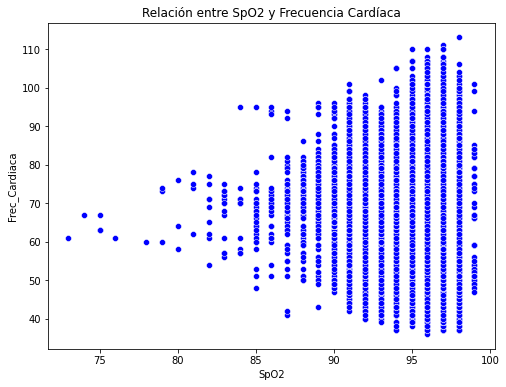

In [123]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_o2ring, x='SpO2', y='Frec_Cardiaca', color='blue')
plt.title('Relación entre SpO2 y Frecuencia Cardíaca')
plt.show()


Los valores atípicos de saturación y frecuencia cardíaca pueden indicar eventos fisiológicos raros que deben ser analizados, especialmente en el presente trabajo puesto que cobran relación con eventos de apnea. Más tarde se abordarán

Para distinguir entre valores atípicos reales y posibles errores de medición, nos basaremos en la literatura:

1. SATURACIÓN

    - Valores de SpO2 entre **90 y 100%** son considerados **normales**, incluso si son atípicos según el IQR o Z-Score **no los eliminaremos**.
    - Valores de SpO2 por **debajo de 85%** pueden indicar **eventos importantes de desaturación**, de manera que **no los eliminamos ya que estudiaremos problemas respiratorios**.
    - Valores de SpO2 por **debajo de 70%** podrían indicar **errores de medición** o situaciones extremadamente graves (poco probables, veremos cuántas hay para considerar elimarlas). 
    
    
2. FRECUENCIA CARDÍACA

    - Valores de frecuencia cardíaca **entre 40 y 110 pulsaciones por minuto** pueden considerarse normales para los estados de sueño y vigilia.
    - Si existen valores **por debajo de 35 o por encima de 120**, podrían seer errores o eventos fisiológicos raros.

In [124]:
# SpO2 < 70% los eliminamos
print(df_o2ring[df_o2ring["SpO2"] < 70])  # Ver cuántos valores hay debajo de 70
df_o2ring = df_o2ring[df_o2ring["SpO2"] >= 70]  # Eliminar solo si hay muy pocos


Empty DataFrame
Columns: [Time, SpO2, Frec_Cardiaca, Movimiento, Paciente_ID, z_spo2, z_fc]
Index: []


In [125]:
# Frec_Cardiaca < 40 y Frec_Cardiaca > 120 los elminamos 
print(df_o2ring[(df_o2ring["Frec_Cardiaca"] < 40) | (df_o2ring["Frec_Cardiaca"] > 120)])
df_o2ring = df_o2ring[(df_o2ring["Frec_Cardiaca"] >= 40) & (df_o2ring["Frec_Cardiaca"] <= 120)]


                      Time  SpO2  Frec_Cardiaca  Movimiento Paciente_ID  \
8829   2025-01-15 00:52:18    96             37           0       Angel   
9837   2025-01-15 01:59:30    96             39           0       Angel   
9991   2025-01-15 02:09:46    97             37           0       Angel   
10384  2025-01-15 02:35:58    95             38           0       Angel   
10434  2025-01-15 02:39:18    96             37           0       Angel   
...                    ...   ...            ...         ...         ...   
104428 2024-12-08 05:48:30    97             39           0       Pablo   
104435 2024-12-08 05:48:58    98             39           0       Pablo   
104544 2024-12-08 05:56:14    97             39           1       Pablo   
104633 2024-12-08 06:02:10    98             39           1       Pablo   
104634 2024-12-08 06:02:14    98             39           1       Pablo   

          z_spo2      z_fc  
8829    0.264294 -2.584499  
9837    0.264294 -2.388349  
9991    0.83

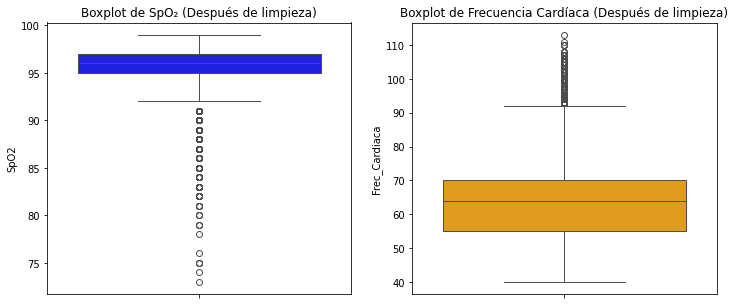

In [126]:
# Visualizaciones para comprobar que los datos tienen sentido
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_o2ring['SpO2'], ax=axes[0], color="blue")
axes[0].set_title("Boxplot de SpO₂ (Después de limpieza)")

sns.boxplot(y=df_o2ring['Frec_Cardiaca'], ax=axes[1], color="orange")
axes[1].set_title("Boxplot de Frecuencia Cardíaca (Después de limpieza)")

plt.show()


In [127]:
print("Tamaño antes de la limpieza:", df_o2ring.shape)

# Filtrado (usando los criterios que definimos antes)
df_o2ring_filtrado = df_o2ring[
    (df_o2ring['SpO2'] >= 70) &
    (df_o2ring['Frec_Cardiaca'] >= 40) &
    (df_o2ring['Frec_Cardiaca'] <= 120)
]

print("Tamaño después de la limpieza:", df_o2ring_filtrado.shape)


Tamaño antes de la limpieza: (160238, 7)
Tamaño después de la limpieza: (160238, 7)


In [128]:
print("Estadísticas antes de la limpieza:")
print(df_o2ring[['SpO2', 'Frec_Cardiaca']].describe())

print("Estadísticas después de la limpieza:")
print(df_o2ring_filtrado[['SpO2', 'Frec_Cardiaca']].describe())


Estadísticas antes de la limpieza:
                SpO2  Frec_Cardiaca
count  160238.000000  160238.000000
mean       95.534455      63.367971
std         1.759115      10.180392
min        73.000000      40.000000
25%        95.000000      55.000000
50%        96.000000      64.000000
75%        97.000000      70.000000
max        99.000000     113.000000
Estadísticas después de la limpieza:
                SpO2  Frec_Cardiaca
count  160238.000000  160238.000000
mean       95.534455      63.367971
std         1.759115      10.180392
min        73.000000      40.000000
25%        95.000000      55.000000
50%        96.000000      64.000000
75%        97.000000      70.000000
max        99.000000     113.000000


In [129]:
iqr_spo2_antes = df_o2ring['SpO2'].quantile(0.75) - df_o2ring['SpO2'].quantile(0.25)
iqr_fc_antes = df_o2ring['Frec_Cardiaca'].quantile(0.75) - df_o2ring['Frec_Cardiaca'].quantile(0.25)

iqr_spo2_despues = df_o2ring_filtrado['SpO2'].quantile(0.75) - df_o2ring_filtrado['SpO2'].quantile(0.25)
iqr_fc_despues = df_o2ring_filtrado['Frec_Cardiaca'].quantile(0.75) - df_o2ring_filtrado['Frec_Cardiaca'].quantile(0.25)

print(f"IQR SpO2 antes: {iqr_spo2_antes}, después: {iqr_spo2_despues}")
print(f"IQR Frecuencia Cardíaca antes: {iqr_fc_antes}, después: {iqr_fc_despues}")


IQR SpO2 antes: 2.0, después: 2.0
IQR Frecuencia Cardíaca antes: 15.0, después: 15.0


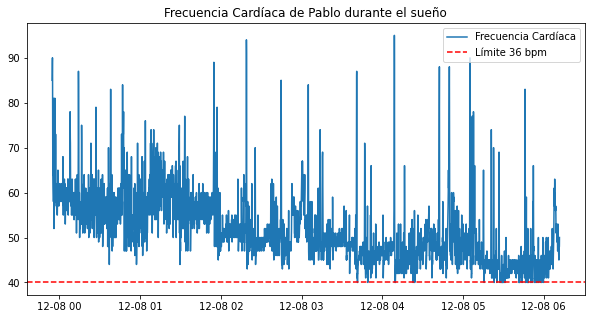

In [131]:
# PABLO TIENE UNA FRECUENCIA MUY MAJA --> BUENA CONDICION FISICA
df_pablo = df_o2ring[df_o2ring["Paciente_ID"] == "Pablo"]
plt.figure(figsize=(10, 5))
plt.plot(df_pablo["Time"], df_pablo["Frec_Cardiaca"], label="Frecuencia Cardíaca")
plt.axhline(y=40, color='r', linestyle='--', label="Límite 36 bpm")
plt.legend()
plt.title("Frecuencia Cardíaca de Pablo durante el sueño")
plt.show()


#### ANÁLISIS INICIAL DEL TEST DE PITTSBURGH


<ipython-input-139-402e85e29b3d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=test_pittsburgh["Calidad_Sueño"], palette="viridis")


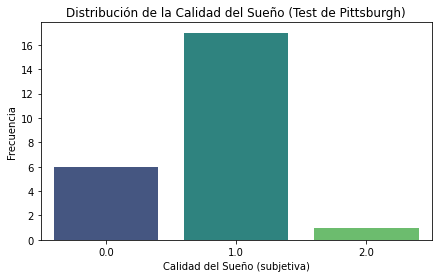

In [139]:
# ANÁLISIS DE LA CALIDAD SUBJETIVA DEL SUEÑO
# Contar frecuencia de cada categoría de calidad del sueño
plt.figure(figsize=(7, 4))
sns.countplot(x=test_pittsburgh["Calidad_Sueño"], palette="viridis")
plt.title("Distribución de la Calidad del Sueño (Test de Pittsburgh)")
plt.xlabel("Calidad del Sueño (subjetiva)")
plt.ylabel("Frecuencia")
plt.show()

<ipython-input-142-020eff87ca3c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=test_pittsburgh["Dormir_Problema"], ax=axes[0], palette="Blues")
<ipython-input-142-020eff87ca3c>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=test_pittsburgh["Despertar_Noche"], ax=axes[1], palette="Oranges")
<ipython-input-142-020eff87ca3c>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=test_pittsburgh["Somnolencia_Dia"], ax=axes[2], palette="Greens")


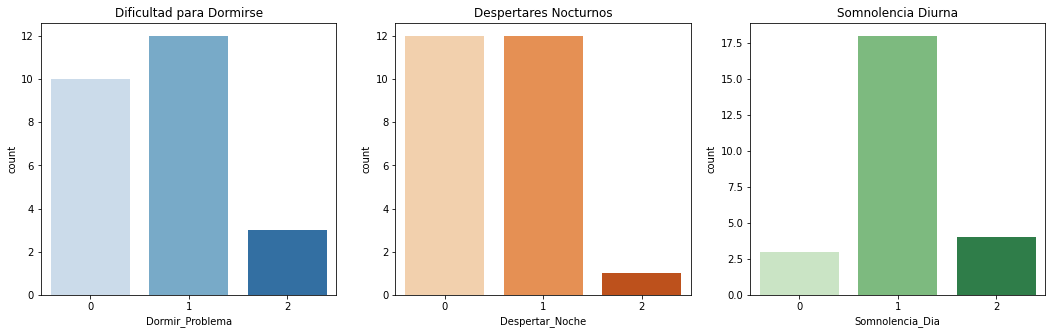

In [142]:
# DISTRIBUCIÓN DE LAS RESPUESTAS EN PREGUNTAS CLAVE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Problemas para quedarse dormido
sns.countplot(x=test_pittsburgh["Dormir_Problema"], ax=axes[0], palette="Blues")
axes[0].set_title("Dificultad para Dormirse")

# Despertares nocturnos
sns.countplot(x=test_pittsburgh["Despertar_Noche"], ax=axes[1], palette="Oranges")
axes[1].set_title("Despertares Nocturnos")

# Somnolencia diurna
sns.countplot(x=test_pittsburgh["Somnolencia_Dia"], ax=axes[2], palette="Greens")
axes[2].set_title("Somnolencia Diurna")

plt.show()


<ipython-input-141-ce711d4dc8d0>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=test_pittsburgh["Calidad_Sueño"], y=test_pittsburgh["Dormir_Problema"], ax=axes[0], palette="coolwarm")
<ipython-input-141-ce711d4dc8d0>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=test_pittsburgh["Calidad_Sueño"], y=test_pittsburgh["Despertar_Noche"], ax=axes[1], palette="coolwarm")


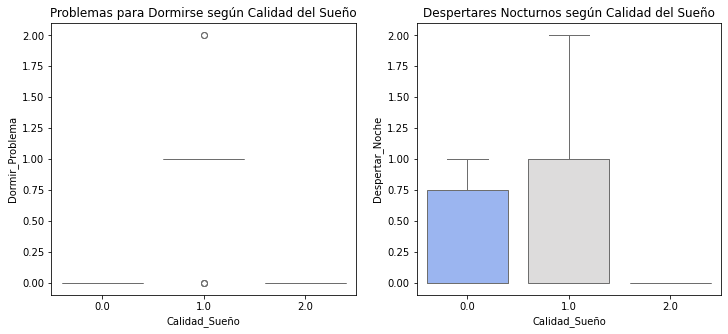

In [141]:
# RELACIÓN ENTRE LA CALIDAD DEL SUEÑO Y RESPUESTAS ESPECÍFICAS
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Relación entre calidad del sueño y problemas para dormirse
sns.boxplot(x=test_pittsburgh["Calidad_Sueño"], y=test_pittsburgh["Dormir_Problema"], ax=axes[0], palette="coolwarm")
axes[0].set_title("Problemas para Dormirse según Calidad del Sueño")

# Relación entre calidad del sueño y despertares nocturnos
sns.boxplot(x=test_pittsburgh["Calidad_Sueño"], y=test_pittsburgh["Despertar_Noche"], ax=axes[1], palette="coolwarm")
axes[1].set_title("Despertares Nocturnos según Calidad del Sueño")

plt.show()


## 4. EXTRACCIÓN DE CARACTERÍSTICAS
 Nos enfocaremos en **tres áreas principales**:

#### A) ESTADÍSTICAS BÁSICAS POR PACIENTE

Para cada pacienre, calculamos:
- Media, mediana y desviación estándar de SpO2 y Frec_Cardiaca.
- Mínimo y máximo de SpO2 y Frec_Cardiaca.
- Porcentaje de tiempo con SpO2 < 90% (posibles desaturaciones).
- Porcentaje de tiempo con Frec_Cardiaca < 50 bpm o > 100 bpm

In [133]:
# Agrupar por paciente y calcular estadísticas básicas
features = df_o2ring.groupby("Paciente_ID").agg(
    SpO2_mean=("SpO2", "mean"),
    SpO2_median=("SpO2", "median"),
    SpO2_std=("SpO2", "std"),
    SpO2_min=("SpO2", "min"),
    SpO2_max=("SpO2", "max"),
    FC_mean=("Frec_Cardiaca", "mean"),
    FC_median=("Frec_Cardiaca", "median"),
    FC_std=("Frec_Cardiaca", "std"),
    FC_min=("Frec_Cardiaca", "min"),
    FC_max=("Frec_Cardiaca", "max"),
    Porc_Desat=("SpO2", lambda x: (x < 90).mean()),  
    Porc_Bradycardia=("Frec_Cardiaca", lambda x: (x < 50).mean()),  
    Porc_Taqui=("Frec_Cardiaca", lambda x: (x > 100).mean())
).reset_index()

display(features.head(20))


,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,FC_max,Porc_Desat,Porc_Bradycardia,Porc_Taqui
0,Alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,95,0.000131,0.150262,0.000000
1,Angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,84,0.002030,0.666715,0.000000
2,Azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,95,0.000299,0.000000,0.000000
3,Carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,110,0.000300,0.000000,0.006308
4,Dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,99,0.009389,0.000481,0.000000
5,Elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,83,0.000156,0.713928,0.000000
6,Esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,113,0.000000,0.000000,0.003361
7,Felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,101,0.007265,0.000000,0.000476
8,Jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,105,0.000000,0.071146,0.000988
9,Jaime2,96.895408,97.0,0.552707,91,98,54.229592,54.0,5.787152,40,87,0.000000,0.196747,0.000000


#### B) VARIABILIDAD Y EVENTOS CRÍTICOS
- Número de caídas bruscas en SpO2 (Ejemplo: bajadas de más de 4% en poco tiempo).
- Número de episodios de taquicardia (>100 bpm) o bradicardia (<50 bpm).

In [135]:
# Detectar cambios bruscos en SpO2
df_o2ring["SpO2_diff"] = df_o2ring.groupby("Paciente_ID")["SpO2"].diff()
df_o2ring["SpO2_drop"] = (df_o2ring["SpO2_diff"] < -4).astype(int)  # Caídas > 4%

# Contar eventos por paciente
eventos = df_o2ring.groupby("Paciente_ID").agg(
    Num_Desaturaciones=("SpO2_drop", "sum"),
    Num_Taqui=("Frec_Cardiaca", lambda x: (x > 100).sum()),
    Num_Brady=("Frec_Cardiaca", lambda x: (x < 50).sum())
).reset_index()

# Unir con las características anteriores
features = features.merge(eventos, on="Paciente_ID")

features.head(20)


,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,FC_max,Porc_Desat,Porc_Bradycardia,Porc_Taqui,Num_Desaturaciones_x,Num_Taqui_x,Num_Brady_x,Num_Desaturaciones_y,Num_Taqui_y,Num_Brady_y
0,Alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,95,0.000131,0.150262,0.000000,0,0,1148,0,0,1148
1,Angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,84,0.002030,0.666715,0.000000,0,0,4597,0,0,4597
2,Azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,95,0.000299,0.000000,0.000000,0,0,0,0,0,0
3,Carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,110,0.000300,0.000000,0.006308,0,42,0,0,42,0
4,Dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,99,0.009389,0.000481,0.000000,0,0,4,0,0,4
5,Elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,83,0.000156,0.713928,0.000000,0,0,4562,0,0,4562
6,Esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,113,0.000000,0.000000,0.003361,0,30,0,0,30,0
7,Felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,101,0.007265,0.000000,0.000476,0,4,0,0,4,0
8,Jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,105,0.000000,0.071146,0.000988,0,2,144,0,2,144
9,Jaime2,96.895408,97.0,0.552707,91,98,54.229592,54.0,5.787152,40,87,0.000000,0.196747,0.000000,0,0,617,0,0,617


#### C) RELACIÓN CON EL MOVIMIENTO
- Promedio y variabilidad del Movimiento.
- Correlación entre Movimiento y SpO2 / Frec_Cardiaca (¿El movimiento afecta las mediciones?).

In [138]:
# Agregar estadísticas de movimiento
mov_features = df_o2ring.groupby("Paciente_ID").agg(
    Movimiento_mean=("Movimiento", "mean"),
    Movimiento_std=("Movimiento", "std"),
    Correlacion_Mov_SpO2=("SpO2", lambda x: x.corr(df_o2ring["Movimiento"])),
    Correlacion_Mov_FC=("Frec_Cardiaca", lambda x: x.corr(df_o2ring["Movimiento"]))
).reset_index()

# Unir con el dataset final
features = features.merge(mov_features, on="Paciente_ID")

features.head(20)


,Paciente_ID,SpO2_mean,SpO2_median,SpO2_std,SpO2_min,SpO2_max,FC_mean,FC_median,FC_std,FC_min,...,Correlacion_Mov_SpO2_x,Correlacion_Mov_FC_x,Movimiento_mean_y,Movimiento_std_y,Correlacion_Mov_SpO2_y,Correlacion_Mov_FC_y,Movimiento_mean,Movimiento_std,Correlacion_Mov_SpO2,Correlacion_Mov_FC
0,Alvaro,95.172644,95.0,1.004068,89,98,54.524738,53.0,5.918163,41,...,0.017662,0.189545,1.405759,7.557643,0.017662,0.189545,1.405759,7.557643,0.017662,0.189545
1,Angel,95.419724,96.0,1.198546,85,98,48.495577,48.0,4.304409,40,...,-0.027561,0.127320,0.392748,3.405878,-0.027561,0.127320,0.392748,3.405878,-0.027561,0.127320
2,Azucena,95.495149,96.0,1.052276,89,98,65.577997,65.0,4.711567,53,...,0.042473,0.231971,0.592924,3.725560,0.042473,0.231971,0.592924,3.725560,0.042473,0.231971
3,Carmen,96.195554,96.0,0.849797,88,99,74.044908,73.0,10.059083,51,...,0.052700,0.181584,1.948783,7.992162,0.052700,0.181584,1.948783,7.992162,0.052700,0.181584
4,Dolores,94.839312,95.0,1.953796,79,99,65.953298,66.0,7.458984,47,...,0.110338,0.175635,0.621088,4.056914,0.110338,0.175635,0.621088,4.056914,0.110338,0.175635
5,Elena,97.372144,98.0,0.771523,89,99,49.151800,48.0,4.050680,41,...,-0.002129,0.035644,0.645227,5.274033,-0.002129,0.035644,0.645227,5.274033,-0.002129,0.035644
6,Esther,96.404727,96.0,0.703272,92,98,74.187633,74.0,6.598287,56,...,0.001618,0.075550,0.443822,3.394345,0.001618,0.075550,0.443822,3.394345,0.001618,0.075550
7,Felix,93.975703,94.0,1.572358,86,98,71.097785,71.0,6.528599,52,...,0.041641,0.082095,1.439614,8.337265,0.041641,0.082095,1.439614,8.337265,0.041641,0.082095
8,Jaime,97.114625,97.0,0.583768,91,98,57.198123,56.0,6.434412,42,...,0.017127,0.081076,0.985178,4.768053,0.017127,0.081076,0.985178,4.768053,0.017127,0.081076
9,Jaime2,96.895408,97.0,0.552707,91,98,54.229592,54.0,5.787152,40,...,0.005539,0.137303,0.868304,5.189322,0.005539,0.137303,0.868304,5.189322,0.005539,0.137303


## 5. UNIÓN DATASETS

In [143]:
# ANTES DE LA UNIÓN....

In [ ]:
# 1. IDENTIFICADORES ÚNICOS en todos los datasets


In [155]:
df_pittsburgh.rename(columns={"ID_Paciente": "Paciente_ID"}, inplace=True)

In [156]:
def normalizar_id(df, columna_nombre):
    df[columna_nombre] = df[columna_nombre].str.strip().str.lower()
    return df

df_o2ring = normalizar_id(df_o2ring, "Paciente_ID")
df_pittsburgh = normalizar_id(test_pittsburgh, "Paciente_ID")
df_personas = normalizar_id(lista_personas, "Paciente_ID")


In [ ]:
# 2. FORMATO DE LAS FECHAS (mismo formato)

In [158]:
# Convertir las fechas a formato datetime
df_o2ring["Time"] = pd.to_datetime(df_o2ring["Time"])
df_pittsburgh["Fecha"] = pd.to_datetime(df_pittsburgh["Fecha"])

In [159]:
def check_dates(df1, df2, id_col, date_col1, date_col2):
    merged = df1[[id_col, date_col1]].merge(df2[[id_col, date_col2]], on=id_col, how="inner")
    merged["Date_Diff"] = (merged[date_col1] - merged[date_col2]).dt.days
    print("Diferencias en días entre fechas:")
    print(merged["Date_Diff"].describe())
    return merged

fecha_check = check_dates(df_o2ring, df_pittsburgh, "Paciente_ID", "Time", "Fecha")

Diferencias en días entre fechas:
count    150866.000000
mean         54.142623
std          96.755903
min         -27.000000
25%          -2.000000
50%          -1.000000
75%          87.000000
max         322.000000
Name: Date_Diff, dtype: float64


In [160]:
# 3. VALORES NULOS

In [161]:
print("Valores nulos antes de imputación:")
print(df_personas["Calidad_Sueño_Subjet"].isnull().sum())

Valores nulos antes de imputación:
0


In [162]:
# 4. NORMALIZACIÓN DE VARIABLES

In [165]:
df_o2ring.head()

,Time,SpO2,Frec_Cardiaca,Movimiento,Paciente_ID,z_spo2,z_fc,SpO2_diff,SpO2_drop
0,2024-11-13 00:26:18,96,73,0,alvaro,0.264294,0.946186,NaN,0
1,2024-11-13 00:26:22,96,73,1,alvaro,0.264294,0.946186,0.0,0
2,2024-11-13 00:26:26,96,74,0,alvaro,0.264294,1.044261,0.0,0
3,2024-11-13 00:26:30,96,73,1,alvaro,0.264294,0.946186,0.0,0
4,2024-11-13 00:26:34,96,72,9,alvaro,0.264294,0.848112,0.0,0


In [166]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

vars_to_normalize = ["SpO2", "Frec_Cardiaca", "Movimiento"]

df_o2ring[vars_to_normalize] = scaler_minmax.fit_transform(df_o2ring[vars_to_normalize])
df_personas["IMC"] = scaler_standard.fit_transform(df_personas[["IMC"]])

print("Preprocesamiento completado. Datos listos para la unión.")

Preprocesamiento completado. Datos listos para la unión.


### UNIÓN

## 6. BALANCEO DE CLASES 
    (opcional, ir mirando los datos que tenemos)

## 6. ENTRENAMIENTO DE MODELOS